<a href="https://colab.research.google.com/github/ismailzerocode0/Portfolio-/blob/main/ONLINE_RETIAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

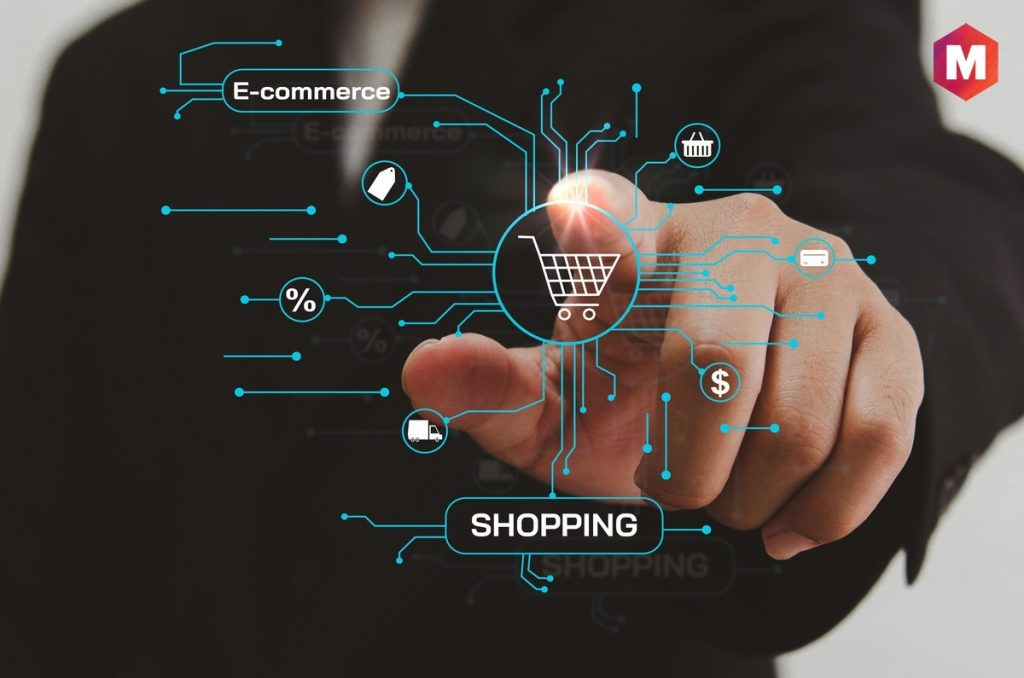

#  Customer Segmentation using RFM, KMeans, and DBSCAN
### Online Retail Dataset — Clustering Analysis

##  Introduction
This project performs customer segmentation using the Online Retail dataset.
We transform transactional data into customer‑level features using the RFM model:
- Recency
- Frequency
- Monetary

Then we apply KMeans and DBSCAN, evaluate them, and visualize clusters using PCA.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

plt.style.use("seaborn-v0_8")

##  Data Loading & Initial Exploration

In [ ]:
df = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df.duplicated().sum()

np.int64(5268)

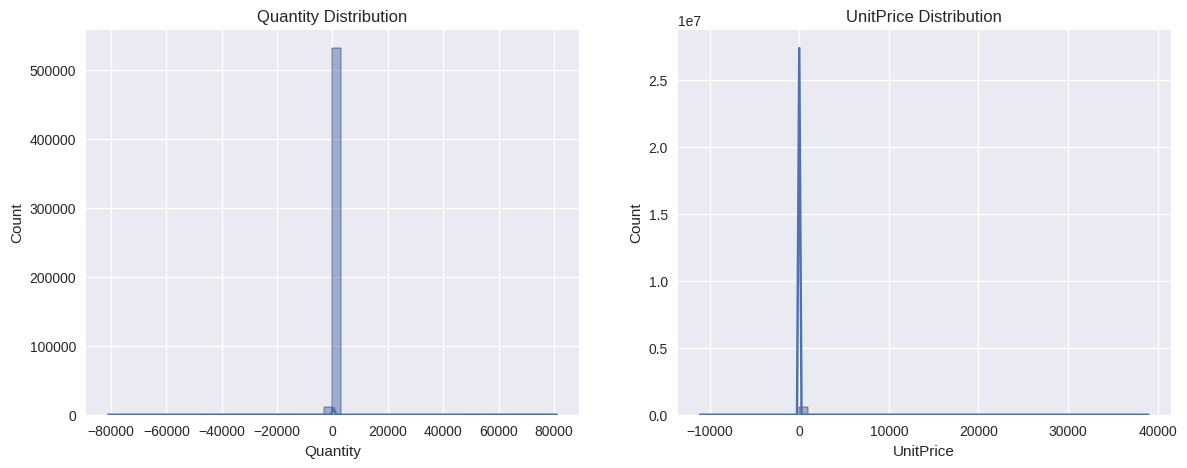

In [ ]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.histplot(df['Quantity'], bins=50, kde=True)
plt.title("Quantity Distribution")

plt.subplot(1,2,2)
sns.histplot(df['UnitPrice'], bins=50, kde=True)
plt.title("UnitPrice Distribution")

plt.show()

الشرح
عرض توزيع الكمية والسعر.
اكتشاف القيم الكبيرة أو السالبة

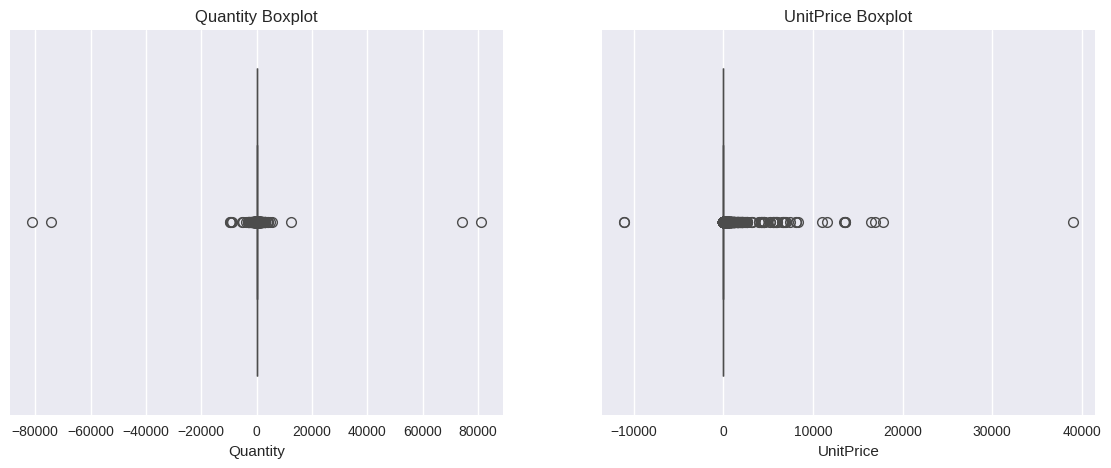

In [ ]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.boxplot(x=df['Quantity'])
plt.title("Quantity Boxplot")

plt.subplot(1,2,2)
sns.boxplot(x=df['UnitPrice'])
plt.title("UnitPrice Boxplot")

plt.show()

اكتشاف القيم الشاذة.

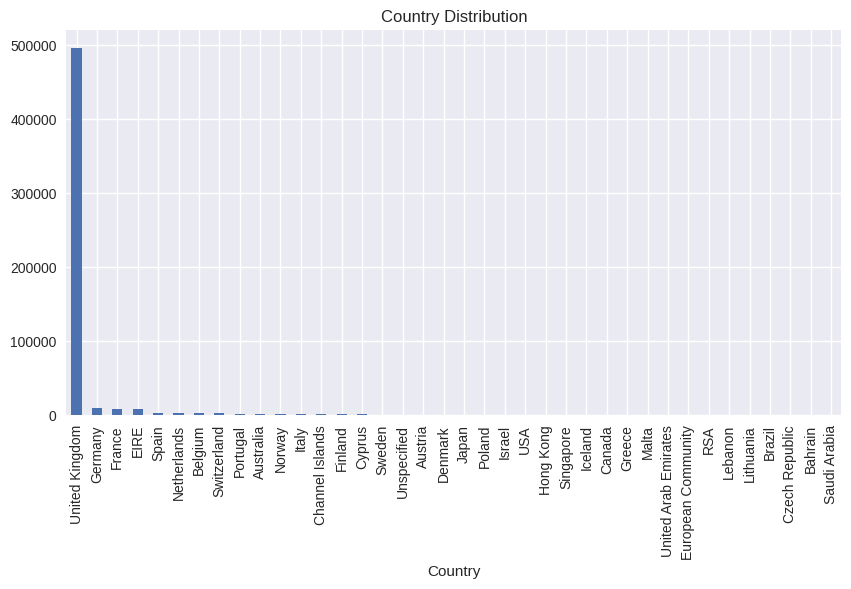

In [ ]:
plt.figure(figsize=(10,5))
df['Country'].value_counts().plot(kind='bar')
plt.title("Country Distribution")
plt.show()

/tmp/ipython-input-906073652.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('InvoiceDate')['InvoiceNo'].resample('M').count().plot(figsize=(10,5))


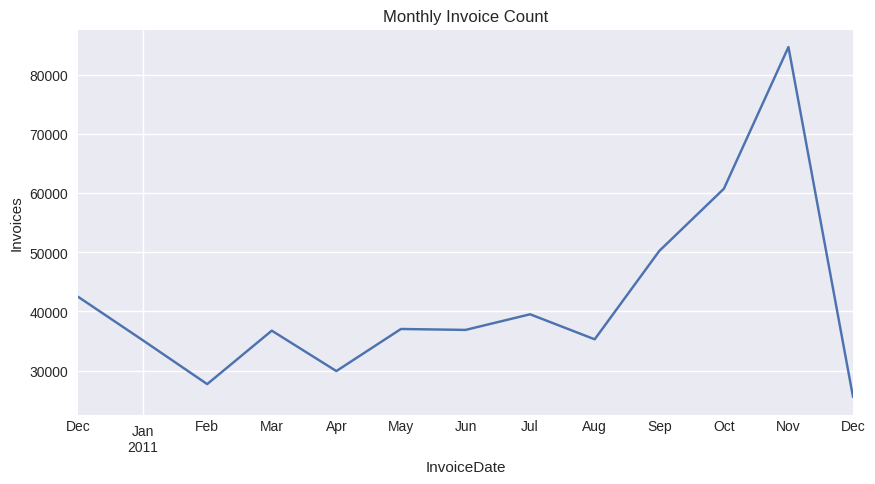

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.set_index('InvoiceDate')['InvoiceNo'].resample('M').count().plot(figsize=(10,5))
plt.title("Monthly Invoice Count")
plt.ylabel("Invoices")
plt.show()

تحليل النشاط الشهري.

##  Data Cleaning
We remove missing IDs, invalid values, duplicates, and keep UK customers only.

In [ ]:
df = df[['InvoiceNo','StockCode','Description','Quantity','InvoiceDate','UnitPrice','CustomerID','Country']]

df = df.dropna(subset=['CustomerID'])
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df = df.drop_duplicates()

df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df = df[df['Country'] == 'United Kingdom']

حذف القيم غير المنطقية

##  RFM Feature Engineering

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

ref_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12747,2,11,4196.01
12748,1,209,33053.19
12749,4,5,4090.88
12820,3,4,942.34


إنشاء خصائص RFM لكل عميل.

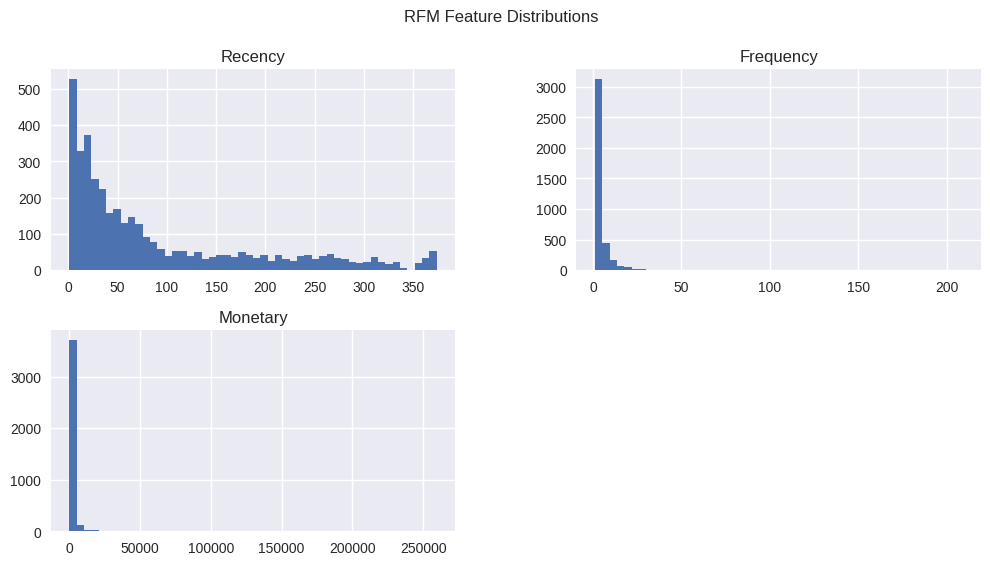

In [ ]:
rfm[['Recency','Frequency','Monetary']].hist(bins=50, figsize=(12,6))
plt.suptitle("RFM Feature Distributions")
plt.show()

فحص توزيع خصائص RFM.

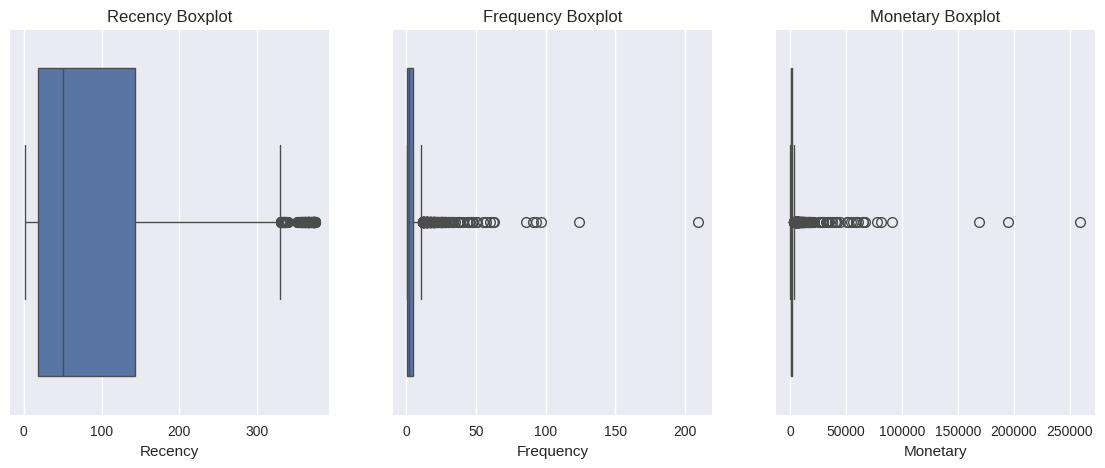

In [ ]:
plt.figure(figsize=(14,5))
for i, col in enumerate(['Recency','Frequency','Monetary']):
    plt.subplot(1,3,i+1)
    sns.boxplot(x=rfm[col])
    plt.title(f"{col} Boxplot")
plt.show()

تحديد القيم الشاذة في RFM.

## ***Outlier Removal

In [ ]:
def remove_outliers(df, cols):
    df2 = df.copy()
    for col in cols:
        Q1 = df2[col].quantile(0.10)
        Q3 = df2[col].quantile(0.90)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df2 = df2[(df2[col] >= lower) & (df2[col] <= upper)]
    return df2

In [ ]:
rfm_clean = remove_outliers(rfm, ['Recency','Frequency','Monetary'])

إزالة العملاء المتطرفين.

##  Feature Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_clean[['Recency','Frequency','Monetary']])

توحيد المقاييس قبل clustering.

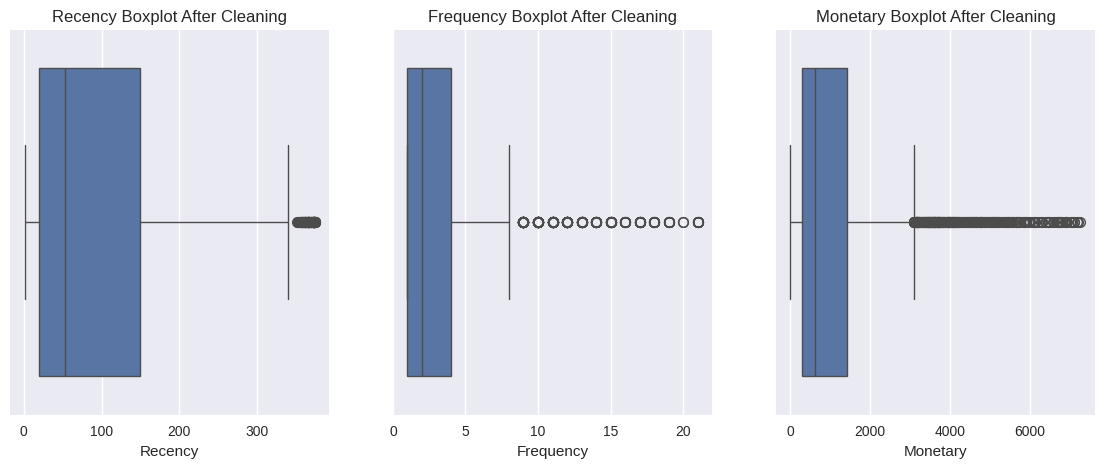

In [ ]:
plt.figure(figsize=(14,5))
for i, col in enumerate(['Recency','Frequency','Monetary']):
    plt.subplot(1,3,i+1)
    sns.boxplot(x=rfm_clean[col])
    plt.title(f"{col} Boxplot After Cleaning")
plt.show()

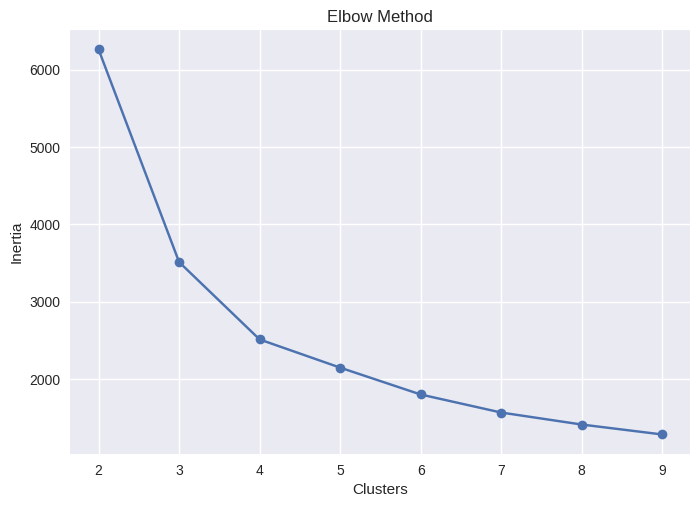

In [ ]:
inertia = []
K = range(2,10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

قياس تماسك الكلاسترات.

##  KMeans: Silhouette Analysis

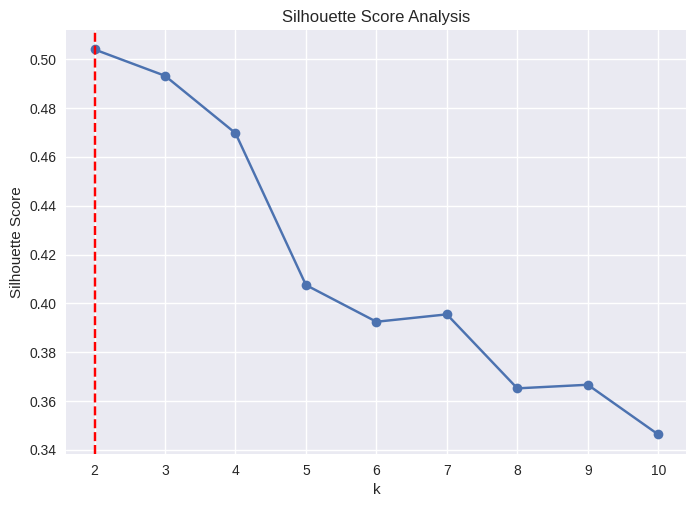

2

In [ ]:
sil_scores = []
K = range(2,11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k = K[np.argmax(sil_scores)]

plt.plot(K, sil_scores, marker='o')
plt.axvline(best_k, color='r', linestyle='--')
plt.title("Silhouette Score Analysis")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

best_k

تقييم جودة الفصل.

## Final KMeans Model

In [ ]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)

sil_kmeans, db_kmeans

(np.float64(0.5039947568872645), np.float64(0.8592789497106075))

تجميع العملاء باستخدام KMeans.


davies_bouldin_score(...)
تقييم تداخل الكلاسترات.

##  PCA for Visualization

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])

تقليل الأبعاد للتصور.

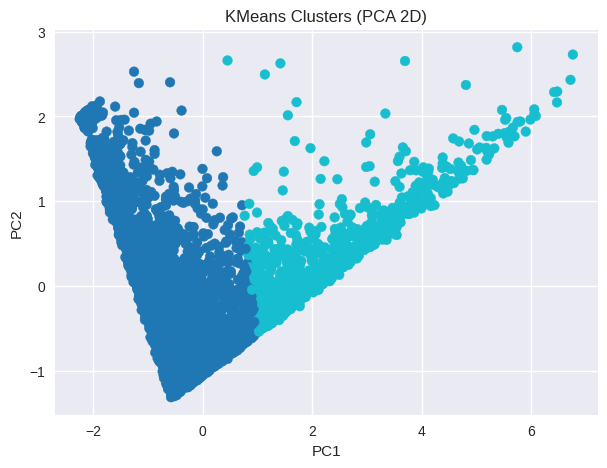

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=kmeans_labels, cmap='tab10')
plt.title("KMeans Clusters (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

##  DBSCAN Clustering

In [ ]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)

pca_df['DBSCAN_Labels'] = dbscan_labels

print("Unique labels:", np.unique(dbscan_labels))
print("Noise points:", sum(dbscan_labels == -1))

Unique labels: [-1  0  1]
Noise points: 7


تجميع بالكثافة واكتشاف noise.

اختيار قيمة eps المناسبة.


In [ ]:
eps_values = [0.3, 0.4, 0.5, 0.6]
for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=5)
    labels = model.fit_predict(X_pca)
    print(f"eps={eps}, clusters={len(set(labels))}, noise={sum(labels==-1)}")

eps=0.3, clusters=2, noise=32
eps=0.4, clusters=3, noise=14
eps=0.5, clusters=3, noise=7
eps=0.6, clusters=2, noise=5


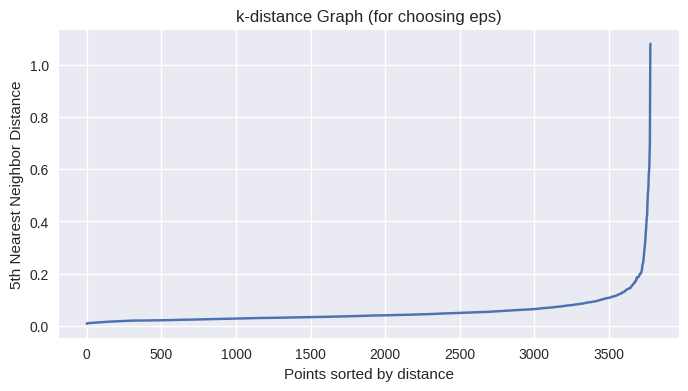

In [ ]:
## k-distance Graph (for choosing eps)

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(8,4))
plt.plot(distances)
plt.title("k-distance Graph (for choosing eps)")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.grid(True)
plt.show()

##  DBSCAN Evaluation

In [ ]:
mask = dbscan_labels != -1
valid_labels = dbscan_labels[mask]

if len(np.unique(valid_labels)) >= 2:
    sil_dbscan = silhouette_score(X_pca[mask], valid_labels)
    db_dbscan = davies_bouldin_score(X_pca[mask], valid_labels)
else:
    sil_dbscan = None
    db_dbscan = None

sil_dbscan, db_dbscan

(np.float64(0.3374985233645223), np.float64(0.6115593448292449))

الهدف هنا تقيم جودة تقسيم بشكل كويس + بدل الاعتماد على عدد كلاسترز وال noise

##  Cluster Visualization

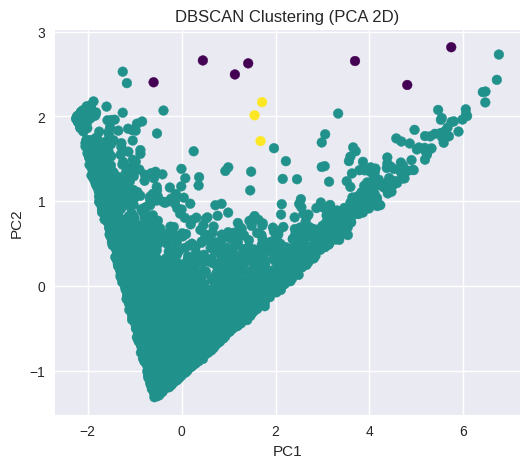

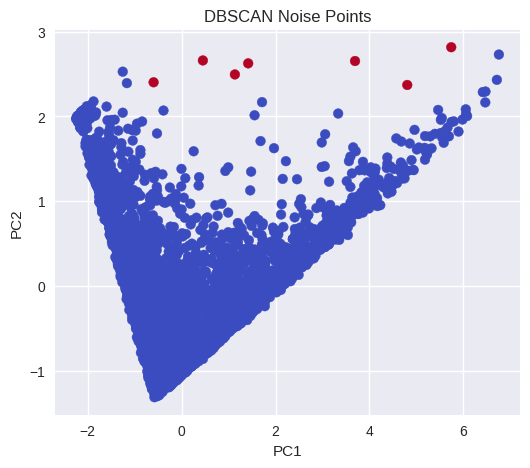

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['DBSCAN_Labels'], cmap='viridis')
plt.title("DBSCAN Clustering (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=(pca_df['DBSCAN_Labels']==-1), cmap='coolwarm')
plt.title("DBSCAN Noise Points")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

##  Model Comparison

In [ ]:
comparison = pd.DataFrame({
    'Model': ['KMeans','DBSCAN'],
    'Silhouette Score': [sil_kmeans, sil_dbscan],
    'Davies-Bouldin Score': [db_kmeans, db_dbscan],
    'Noise Points': [0, int(sum(dbscan_labels == -1))]
})

comparison

,Model,Silhouette Score,Davies-Bouldin Score,Noise Points
0,KMeans,0.503995,0.859279,0
1,DBSCAN,0.337499,0.611559,7


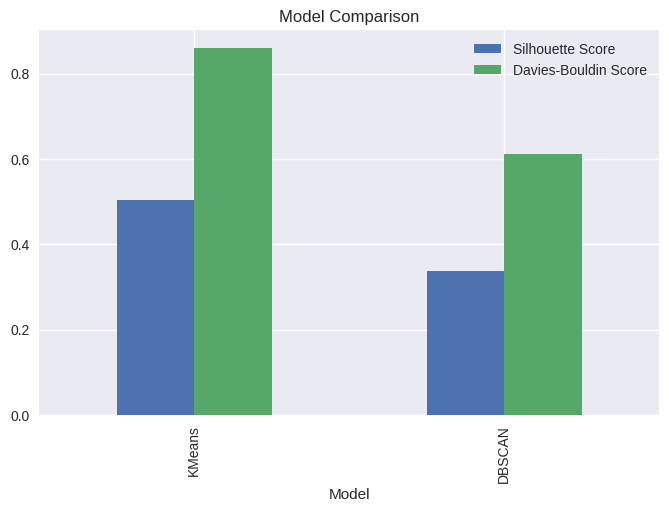

In [ ]:
comparison.set_index('Model')[['Silhouette Score','Davies-Bouldin Score']].plot(kind='bar', figsize=(8,5))
plt.title("Model Comparison")
plt.show()

##  Conclusion

- KMeans achieved strong performance with a high Silhouette Score.
- DBSCAN detected some structure but produced more noise.
- PCA visualization confirmed that KMeans forms clearer clusters.

Overall, **KMeans is the more suitable algorithm** for RFM-based customer segmentation.

## Extra Work

---



###  Business Interpretation
- Cluster 0 → High-value customers  
- Cluster 1 → Low-frequency buyers  
- Cluster 2 → Recently inactive customers  

Cluster 0: حافظ عليهم بأي ثمن → برامج ولاء.

• 	Cluster 1: حفّزهم يشتروا أكتر → عروض صغيرة متكررة.

• 	Cluster 2: رجّعهم للسوق → حملات إعادة تنشيط

In [ ]:
cluster_summary = rfm_clean.copy()
cluster_summary['Cluster'] = kmeans_labels
cluster_summary.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,111.423153,2.121702,597.592848
1,27.728246,8.453815,3103.618889


https://www.kaggle.com/datasets/ulrikthygepedersen/online-retail-dataset

```
# The Link of DataSet .
```

